# [LAB-11] 1. 시계열 데이터의 이해 - 연습문제 풀이

> **문제**
>
> `temperatures_seoul` 데이터는 1973년 07월 ~ 2023년 08월까지 서울의 월평균 기온을 조사한 자료이다.
> 이 데이터의 **정상성 여부를 확인**하고 정상성 확보를 위한 **데이터 전처리를 수행**하시오.
> 전처리 수행 후 총 몇 번의 변환이 적용되었는지 **$d$, $D$, $s$ 값**을 답하시오.

본문에서 항공 승객 수 데이터로 배운 절차를 그대로 적용한다.

| 단계 | 무엇을 하는가 |
|---|---|
| ① 관찰 | 그래프로 추세 · 계절성 · 변동폭 확인 |
| ② 진단 | 구간별 평균/분산, 이동평균/이동표준편차 비교 |
| ③ 검정 | ADF 검정으로 단위근 존재 여부 판정 |
| ④ 처방 | 분산 → 변환, 추세 → 차분, 계절성 → 계절차분 |
| ⑤ 검증 | 조합별로 다시 ADF 검정하여 최선을 선택 |

> ⚠️ **이 데이터는 항공 승객 수와 성격이 다르다.** 같은 절차를 밟되 **결론은 달라진다.**

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, Series
import numpy as np

# 데이터 정상성 확인을 위한 ADF 검정
from statsmodels.tsa.stattools import adfuller

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 불러오기

In [2]:
origin = load_data('temperatures_seoul')

print(f"데이터셋 크기: {origin.shape[0]}행 {origin.shape[1]}열")
origin.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)


데이터셋 크기: 602행 2열


,날짜,평균기온(℃)
0,1973-07-01,26.816
1,1973-08-01,25.884
2,1973-09-01,20.323
3,1973-10-01,13.039
4,1973-11-01,4.723


### 3. 시계열 인덱스 설정

`날짜` 컬럼은 이미 `datetime64` 타입이므로 형변환 없이 바로 인덱스로 지정한다.

In [3]:
df1 = origin.set_index("날짜")

print("인덱스 타입:", type(df1.index))
print("기간:", df1.index[0].strftime("%Y-%m"), "~", df1.index[-1].strftime("%Y-%m"))
df1.head()

인덱스 타입: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
기간: 1973-07 ~ 2023-08


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


## #02. 시계열의 첫 관찰

검정 통계량보다 먼저 **선 그래프 한 장**으로 세 가지를 확인한다.

| 확인 항목 | 무엇을 보는가 |
|---|---|
| ① 추세 | 전체적으로 올라가는가, 내려가는가, 수평인가 |
| ② 계절성 | 일정한 주기로 같은 모양이 반복되는가 |
| ③ 변동폭 | 위아래로 흔들리는 폭이 시간이 지나며 **커지는가** |

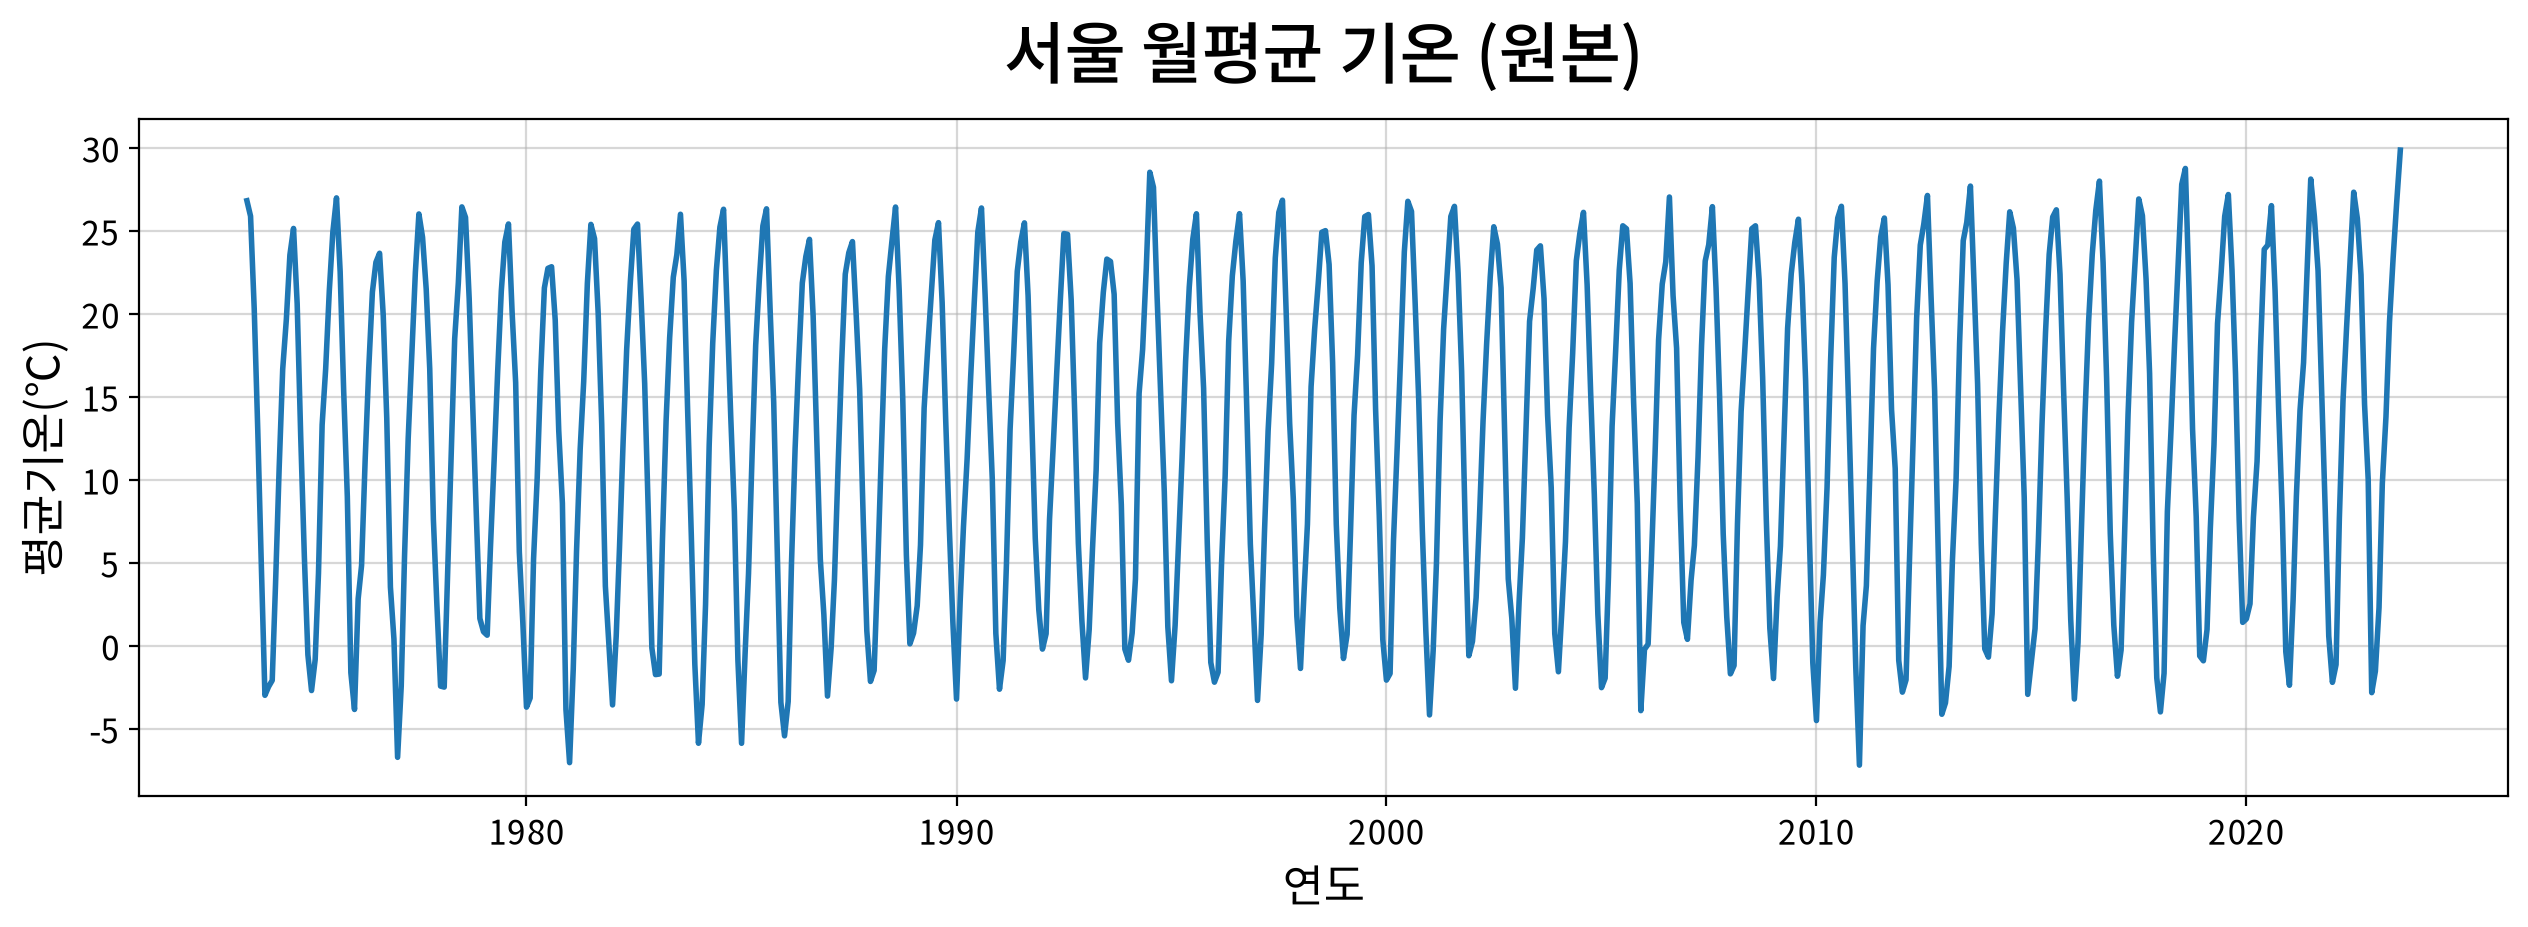

In [4]:
my_plot.lineplot(data=df1, x=df1.index, y="평균기온(℃)",
                 title="서울 월평균 기온 (원본)",
                 xlabel="연도", ylabel="평균기온(℃)",
                 width=1280, height=480)

#### 💡 인사이트

| 확인 항목 | 관찰 결과 |
|---|---|
| ① 추세 | 거의 **수평**이다. 50년간 완만하게 오르긴 하지만 눈에 띄는 우상향은 아니다 |
| ② 계절성 | **매년 똑같은 모양이 반복**된다. 여름 봉우리와 겨울 골이 아주 뚜렷하다 → 주기 12개월 |
| ③ 변동폭 | 진폭이 처음부터 끝까지 **거의 일정**하다. 뒤로 갈수록 커지지 않는다 |

> ★ 항공 승객 수와 정반대다.
> 항공 데이터는 **추세 + 계절성 + 변동폭 증가** 세 가지를 모두 갖고 있었지만,
> 이 데이터는 **계절성 하나만** 두드러진다.
> 처방도 그만큼 줄어들 것이라고 미리 예상할 수 있다.

## #03. 정상성(Stationarity) 확인

### 1. 구간을 나눠서 비교하기

정상성의 정의가 "어느 구간을 잘라도 비슷하다"이므로, 실제로 잘라서 비교한다.

In [5]:
size = len(df1) // 3 # 데이터를 3개 구간으로 나눔
parts = []

for i in range(3):  # 구간수 만큼 반복
    # 구간의 시작 위치 ~ 끝 위치 사이를 자름
    part = df1['평균기온(℃)'].iloc[i * size : (i + 1) * size]

    # 구간내 평균과 표준편차를 계산하여 리스트에 추가
    parts.append({
        "구간": f"구간 {i + 1}",
        "시작": part.index[0].strftime("%Y-%m"),
        "종료": part.index[-1].strftime("%Y-%m"),
        "평균": round(part.mean(), 2),
        "표준편차": round(part.std(), 2),
    })

DataFrame(parts)

,구간,시작,종료,평균,표준편차
0,구간 1,1973-07,1990-02,11.850,10.060
1,구간 2,1990-03,2006-10,12.970,9.590
2,구간 3,2006-11,2023-06,12.860,10.080


#### 💡 인사이트

- **평균**: 11.85 → 12.97 → 12.86 으로 **거의 변하지 않는다.** → **조건 ① 충족 (추세 없음)**
- **표준편차**: 10.06 → 9.59 → 10.08 로 **거의 일정하다.** → **조건 ② 충족 (변동폭 일정)**

> 항공 데이터는 평균이 158 → 269 → 413, 표준편차가 33 → 56 → 79 로 **둘 다 계속 커졌다.**
> 이 데이터는 **두 조건 모두 통과**한다. 즉 **차분도 변환도 필요 없어 보인다.**

> ⚠️ 참고 — 602는 3으로 나누어떨어지지 않아 `602 // 3 = 200`, 마지막 **2개월이 빠진다.**
> 게다가 구간 길이 200개월은 12의 배수가 아니라 구간마다 계절 구성이 조금씩 다르다.
> 이 데이터는 추세가 없어 결론이 바뀌지 않지만, 원칙적으로 **구간 길이는 계절 주기의 배수**로 잡는 것이 좋다.

### 2. 이동평균과 이동표준편차

구간을 3개로 자르는 대신, **1년(12개월)짜리 창을 옆으로 밀면서** 평균과 표준편차를 계산하면
변화의 모습을 연속적으로 볼 수 있다.

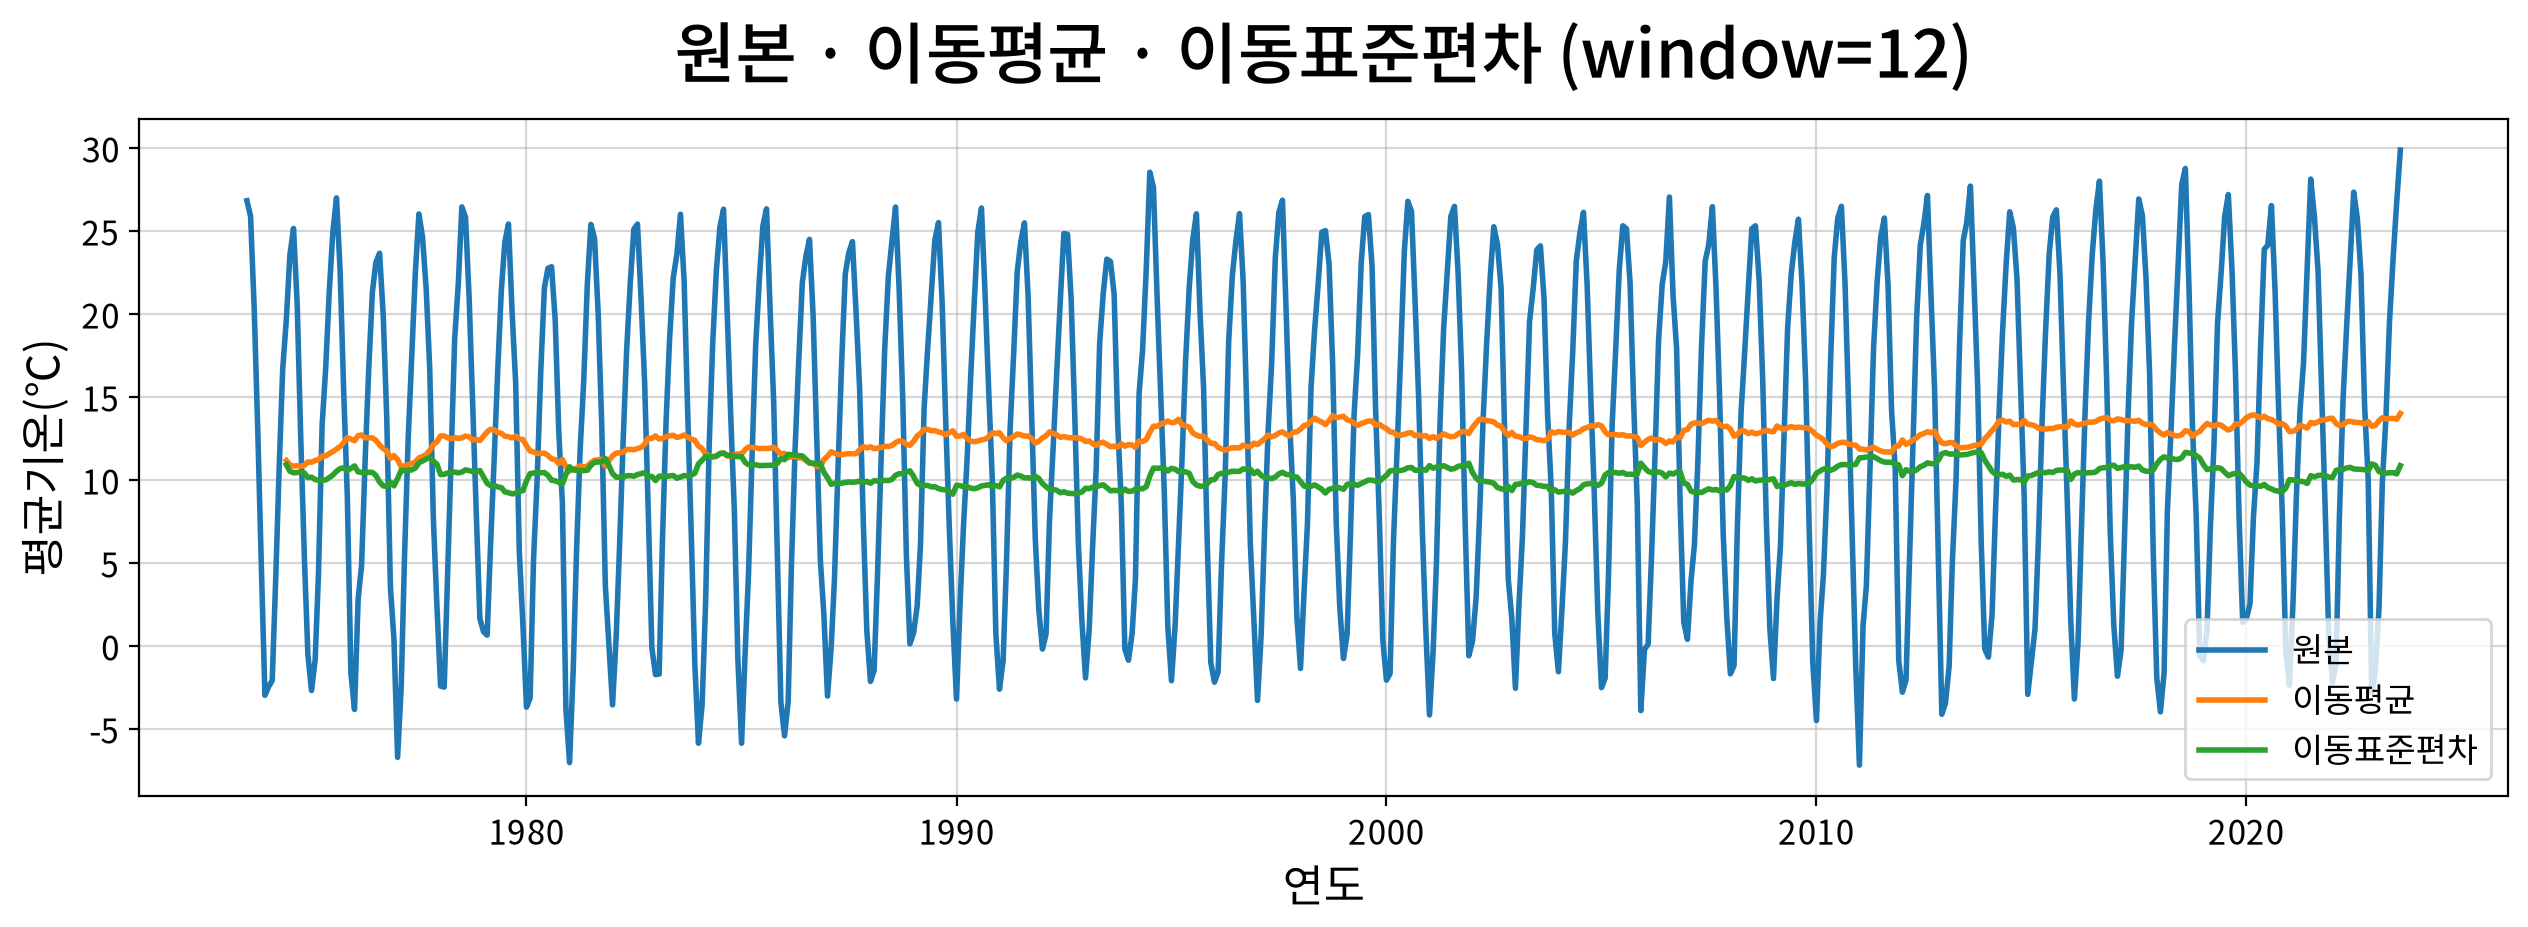

In [6]:
window = 12   # 월간 데이터이므로 1년 = 12개월

roll_mean = df1['평균기온(℃)'].rolling(window).mean()
roll_std  = df1['평균기온(℃)'].rolling(window).std()

fig, ax = my_plot.init(width=1280, height=480,
                       title=f"원본 · 이동평균 · 이동표준편차 (window={window})",
                       xlabel="연도", ylabel="평균기온(℃)")

my_plot.lineplot(x=df1.index, y=df1['평균기온(℃)'], label="원본", ax=ax)
my_plot.lineplot(x=roll_mean.index, y=roll_mean, label="이동평균", ax=ax)
my_plot.lineplot(x=roll_std.index, y=roll_std, label="이동표준편차", ax=ax)

ax.legend()
my_plot.show()

#### 💡 인사이트

- **이동평균**이 10.5 ~ 14.0 사이의 좁은 폭에서 **거의 수평**으로 움직인다 → 평균이 일정하다.
- **이동표준편차**도 9.1 ~ 11.7 사이에서 **거의 수평**이다 → 분산이 일정하다.

> 항공 데이터에서는 두 선이 나란히 우상향했다. 여기서는 둘 다 수평선에 가깝다.
> **원본 상태에서 이미 정상 시계열의 모습에 가깝다는 뜻이다.**

## #04. ADF 검정

그래프는 주관적이므로 통계적 가설검정으로 판정한다. 본문에서 만든 함수를 그대로 쓴다.

In [7]:
def adf_test(data, name):
    x = Series(data).dropna()                       # 결측치 제거
    stat, pvalue, lag, _, crit, _ = adfuller(x)     # ADF 검정 수행

    return {
        "대상": name,
        "관측치 수": len(x),
        "검정통계량(ADF)": round(stat, 3),      # 검정 통계량
        "p-value": round(pvalue, 3),          # p-value
        "사용 시차": lag,                      # 사용된 시차 수
        "1% 기각값": round(crit["1%"], 3),
        "5% 기각값": round(crit["5%"], 3),
        "10% 기각값": round(crit["10%"], 3),
        "판정": "정상" if pvalue < 0.05 else "비정상",
    }

In [8]:
r_origin = adf_test(df1["평균기온(℃)"], "원본")

Series(r_origin)

대상               원본
관측치 수           602
검정통계량(ADF)   -3.877
p-value       0.002
사용 시차            14
1% 기각값       -3.442
5% 기각값       -2.866
10% 기각값      -2.569
판정               정상
dtype: object

#### 💡 인사이트 - 이 문제에서 가장 조심해야 할 지점 ★

**원본이 이미 "정상" 판정을 받았다.** (ADF = -3.877, p = 0.002)

항공 데이터의 원본은 ADF = +0.815, p = 0.992 로 명백한 비정상이었는데, 여기서는 정반대다.

| 항목 | 항공 승객 수 (원본) | 서울 기온 (원본) |
|---|---|---|
| 검정통계량 | +0.815 | **-3.877** |
| p-value | 0.992 | **0.002** |
| 판정 | 비정상 | **정상** |

> ★ **그런데 그래프에는 계절성이 그렇게 뚜렷한데 왜 정상이라고 나오는가?**
>
> **ADF 검정은 단위근(추세)만 본다.** 매년 똑같이 반복되는 계절성은 단위근이 아니다.
> 여름에 올라간 만큼 겨울에 내려와서 **평균으로 되돌아오기 때문**이다.
> 즉 ADF 입장에서는 "정처 없이 떠돌지 않으므로 정상"이 맞다.
>
> **그래서 p-value만 보고 "전처리 끝"이라고 판단하면 안 된다.**
> 계절성이 남아 있으면 모형이 그 반복 패턴을 매번 다시 학습해야 하므로,
> **계절성은 ADF와 별개로 제거 대상**이다.

## #05. 처방 (1) - 변환 (Transformation)

**변환은 분산 문제(조건 ②)를 푸는 도구다.** 이 데이터에 필요한지 먼저 확인한다.

In [9]:
# 연도별 표준편차로 변동폭이 커지는지 확인
std_year = df1['평균기온(℃)'].groupby(df1.index.year).std()

print(f"연도별 표준편차 - 최소: {std_year.min():.3f}, 최대: {std_year.max():.3f}")
print(f"최대/최소 비율: {std_year.max() / std_year.min():.2f}배")

# 로그변환이 가능한지 확인 (0 이하의 값이 있으면 불가)
print(f"\n0℃ 이하인 달: {(df1['평균기온(℃)'] <= 0).sum()}개월 / 전체 {len(df1)}개월")
print(f"최저 기온: {df1['평균기온(℃)'].min():.2f}℃")

연도별 표준편차 - 최소: 9.137, 최대: 11.985
최대/최소 비율: 1.31배

0℃ 이하인 달: 90개월 / 전체 602개월
최저 기온: -7.18℃


#### 💡 인사이트

**변환은 쓰지 않는다.** 두 가지 이유가 모두 성립한다.

| 이유 | 근거 |
|---|---|
| ① **필요가 없다** | 연도별 표준편차 최대/최소 비율이 **1.31배**다. 항공 데이터는 **5.67배**였다 |
| ② **쓸 수도 없다** | 영하인 달이 **90개월** 있고 최저 -7.18℃다. **로그는 0 이하에서 정의되지 않는다** |

> ★ 기온처럼 **0을 지나는 데이터(영상·영하)** 에는 로그변환을 적용할 수 없다.
> 로그변환은 "몇 % 성장" 같은 **비율로 커지는 양수 데이터**를 위한 도구다.
> 승객 수·매출·인구는 되지만 기온·수익률·위도는 안 된다.

> 그래서 이 문제의 답에는 **변환이 들어가지 않는다.**

## #06. 처방 (2) - 차분 (Differencing)

### 1. 일반차분이 필요한가 - 과대차분 확인

차분을 반복하며 **표준편차가 어떻게 변하는지** 관찰한다.

In [10]:
over_diff = []                       # 차분 횟수별 ADF 검정 결과를 담을 리스트
tmp = df1["평균기온(℃)"].copy()      # 원본 데이터를 복사하여 차분 수행

for i in range(4):               # 0차 ~ 3차 차분까지 반복
    r = adf_test(tmp, f"{i}차 차분" if i > 0 else "원본")   # ADF 검정 수행
    r["표준편차"] = round(tmp.std(), 2)                     # 표준편차 계산
    over_diff.append(r)         # 결과를 리스트에 추가
    tmp = tmp.diff().dropna()   # 다음 차분을 위해 1차 차분 수행 후 결측치 제거

DataFrame(over_diff)[["대상", "관측치 수", "검정통계량(ADF)", "p-value", "판정", "표준편차"]]

,대상,관측치 수,검정통계량(ADF),p-value,판정,표준편차
0,원본,602,-3.877,0.002,정상,9.930
1,1차 차분,601,-10.529,0.000,정상,5.410
2,2차 차분,600,-13.340,0.000,정상,3.980
3,3차 차분,599,-18.990,0.000,정상,5.400


#### 💡 인사이트

| 차수 | p-value | 표준편차 | 판단 |
|---|---|---|---|
| 원본 | 0.002 | **9.93** | 이미 정상 |
| 1차 차분 | 0.000 | 5.41 | |
| 2차 차분 | 0.000 | 3.98 | |
| 3차 차분 | 0.000 | 5.40 ↑ | 분산 증가 |

- 모든 차수가 "정상"이다. **p-value로는 아무것도 고를 수 없다.**
- 표준편차만 보면 2차 차분이 최소지만, **이 감소는 추세를 없앤 것이 아니라 계절 진동을 깎아낸 결과**다.
- 애초에 **#03에서 추세가 없다는 것을 확인**했다. 없는 추세를 지우려고 차분할 이유가 없다.

> ★ **차분은 "추세가 있을 때" 쓰는 도구다.** p-value나 표준편차가 좋아 보인다고 쓰는 것이 아니다.
> 남은 문제가 무엇인지 먼저 진단하고, 그 문제에 맞는 처방을 골라야 한다.
> 이 데이터에 남은 문제는 추세가 아니라 **계절성**이다.

### 2. 계절차분 (Seasonal Differencing)

일반 차분이 **직전 값**과 비교했다면, 계절차분은 **작년 같은 달**과 비교한다.

$$\Delta_{12} \, y_t = y_t - y_{t-12}$$

- 월간 데이터이고 매년 같은 모양이 반복되므로 계절 주기는 $s = 12$ 다.
- `diff(12)`로 수행하며 앞의 12개 행이 결측치가 된다.

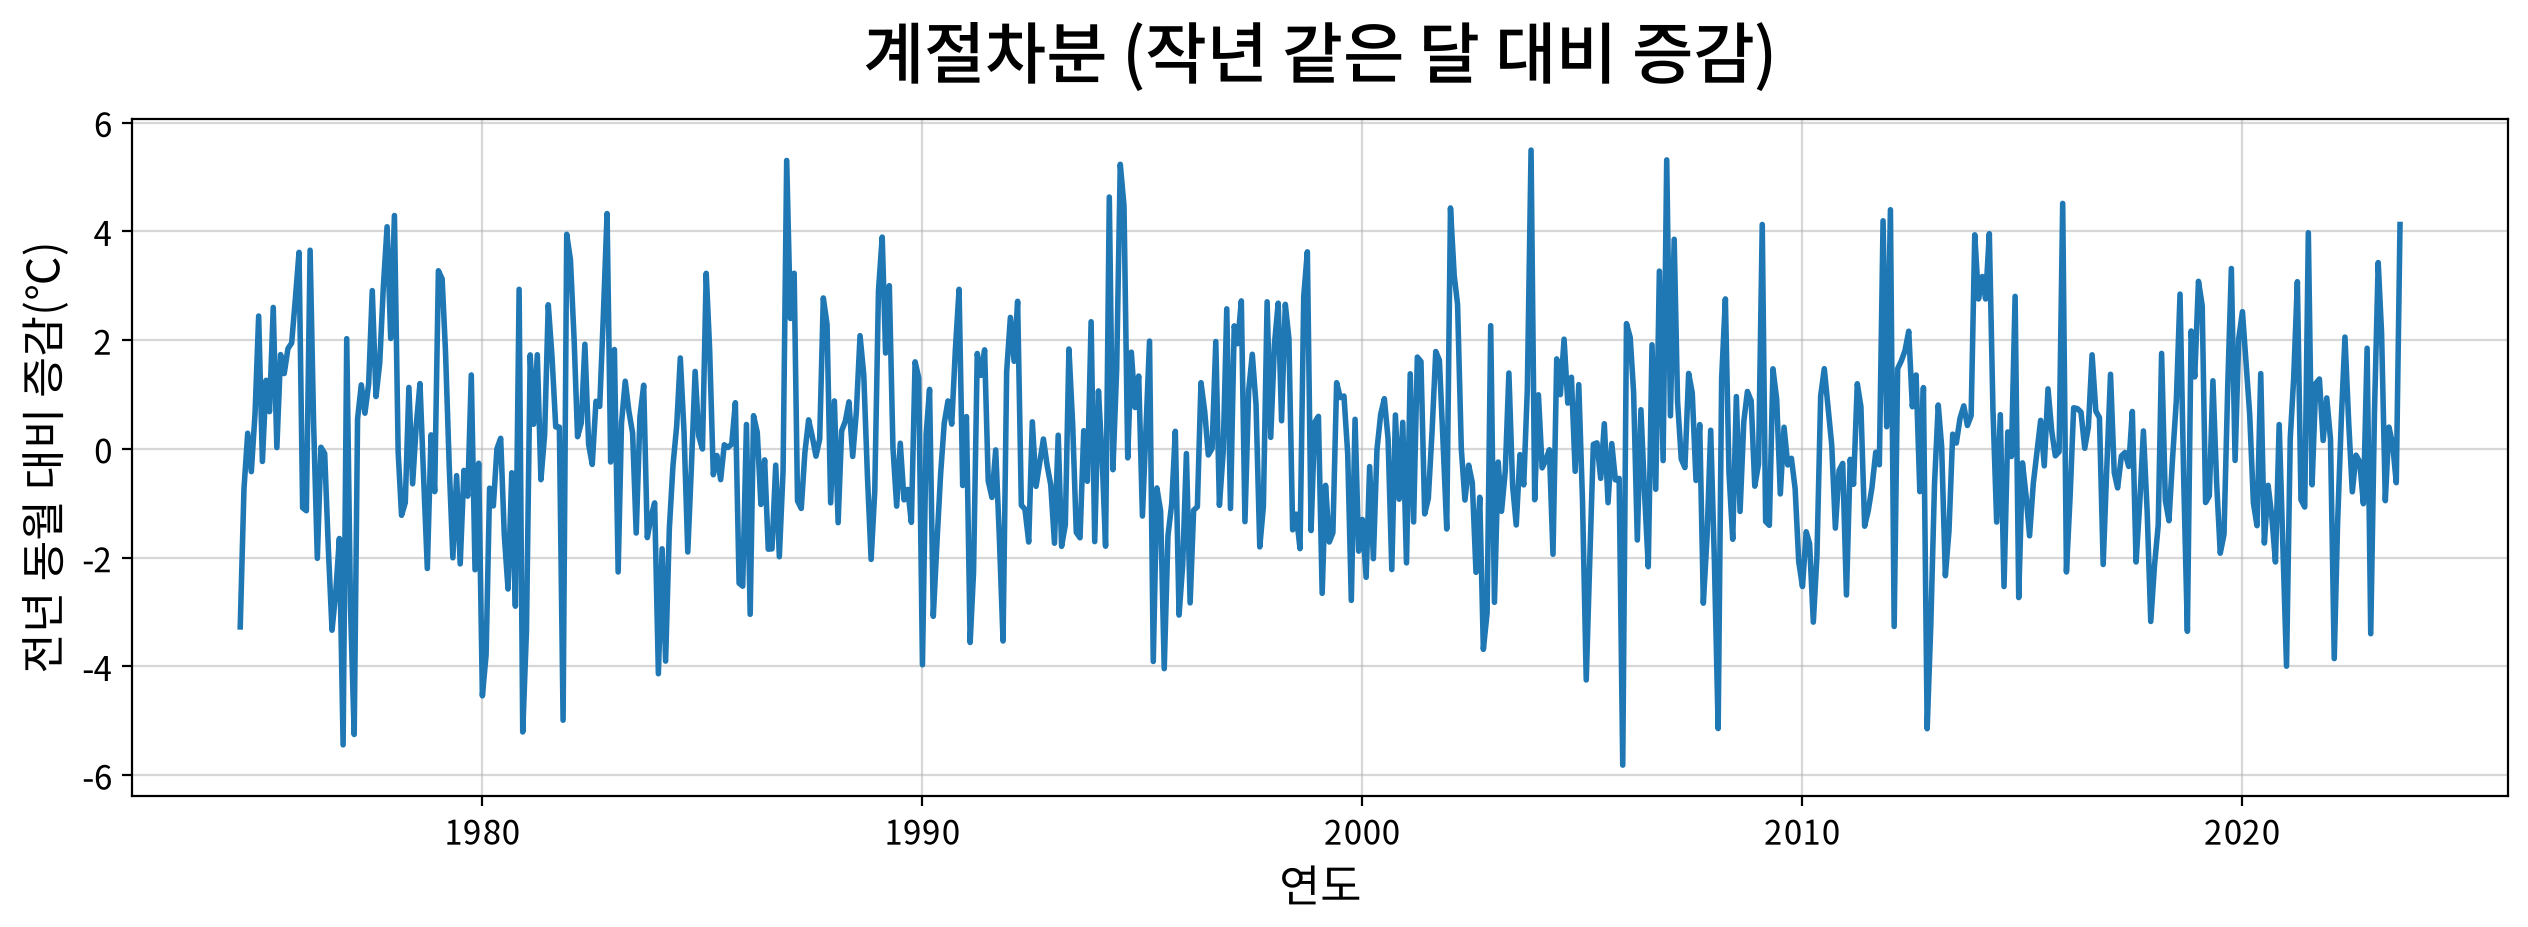

대상            계절차분(12)
관측치 수              590
검정통계량(ADF)      -8.829
p-value          0.000
사용 시차               12
1% 기각값          -3.442
5% 기각값          -2.867
10% 기각값         -2.569
판정                  정상
dtype: object

In [11]:
df3 = df1["평균기온(℃)"].diff(12).dropna()

my_plot.lineplot(x=df3.index, y=df3, title="계절차분 (작년 같은 달 대비 증감)",
                 xlabel="연도", ylabel="전년 동월 대비 증감(℃)",
                 width=1280, height=480)

r_ds = adf_test(df3, "계절차분(12)")    # ADF 검정 수행
Series(r_ds)

#### 💡 인사이트

- 그래프에서 **매년 반복되던 봉우리와 골이 완전히 사라졌다.** 0을 중심으로 무작위로 흩어진다.
- ADF = **-8.829**, p = 0.000 으로 원본(-3.877)보다 **훨씬 강한 정상성**을 얻었다.
- 표준편차가 **9.93 → 1.88 로 5분의 1 이하**가 되었다.

> ★ 표준편차가 이렇게 줄었다는 것은 **원본 변동의 대부분이 계절성이었다**는 뜻이다.
> 서울의 기온은 "올해가 작년보다 더운가"보다 **"지금이 여름인가 겨울인가"** 로 거의 결정된다.
> 그 계절 성분을 걷어내자 ±2℃ 남짓의 잔변동만 남았다.

## #07. 전처리 조합 비교 - 무엇을 쓸 것인가 ★

가능한 조합을 한꺼번에 비교한다.
**로그변환은 영하 값 때문에 적용할 수 없으므로 조합에서 제외**한다.

In [12]:
s = df1["평균기온(℃)"]

combos = {
    "① 원본": s,
    "② 1차 차분": s.diff(),
    "③ 2차 차분": s.diff().diff(),
    "④ 계절차분(12)": s.diff(12),
    "⑤ 1차 차분 + 계절차분(12)": s.diff().diff(12),
}

In [13]:
report = []     # ADF 검정 결과를 담을 리스트

for name, x in combos.items():  # combos 딕셔너리의 key, value를 순회
    r = adf_test(x, name)       # ADF 검정 수행
    r["표준편차"] = round(x.dropna().std(), 3)  # 표준편차 계산
    report.append(r)            # 결과를 리스트에 추가

# ADF 검정 결과를 데이터프레임으로 변환하여 출력
DataFrame(report)[["대상", "관측치 수", "검정통계량(ADF)", "p-value", "5% 기각값", "표준편차", "판정"]]

,대상,관측치 수,검정통계량(ADF),p-value,5% 기각값,표준편차,판정
0,① 원본,602,-3.877,0.002,-2.866,9.932,정상
1,② 1차 차분,601,-10.529,0.000,-2.866,5.407,정상
2,③ 2차 차분,600,-13.340,0.000,-2.867,3.982,정상
3,④ 계절차분(12),590,-8.829,0.000,-2.867,1.881,정상
4,⑤ 1차 차분 + 계절차분(12),589,-10.251,0.000,-2.867,2.371,정상


#### 💡 인사이트

| 조합 | p-value | 표준편차 | 평가 |
|---|---|---|---|
| ① 원본 | 0.002 | 9.932 | 정상 판정이지만 **계절성이 그대로 남아 있다** |
| ② 1차 차분 | 0.000 | 5.407 | 없는 추세를 지웠다 |
| ③ 2차 차분 | 0.000 | 3.982 | 과대차분 |
| **④ 계절차분(12)** | **0.000** | **1.881 ← 최소** | **계절성만 정확히 제거 — 최선** |
| ⑤ 1차 차분 + 계절차분(12) | 0.000 | 2.371 ↑ | 불필요한 차분을 더해 **분산이 다시 커졌다** |

> ★ **판정 기준은 p-value가 아니라 표준편차다.**
> 다섯 조합 모두 p < 0.05 로 "정상"이므로 p-value로는 우열을 가릴 수 없다.
> **표준편차가 최소가 되는 ④를 고른다.**
>
> ⑤를 보면 규칙이 왜 필요한지 분명해진다. 계절차분에 1차 차분을 **더했더니**
> 표준편차가 1.881 → **2.371로 오히려 커졌다.** 없던 노이즈를 만들어낸 것이다.
> 이것이 본문에서 배운 **과대차분(over-differencing)** 이다.

> ★ **결론: ④ 계절차분(12) 한 번만 적용한다.**

## #08. 정답

### 문제의 답

| 항목 | 값 | 근거 |
|---|---|---|
| 변환 | **없음** | 연도별 표준편차 비율 1.31배로 분산이 일정하고, 영하 값(90개월)이 있어 로그 적용 불가 |
| 일반차분 횟수 | **0회** | 구간별 평균 11.85 → 12.97 → 12.86, 이동평균 수평 → **추세가 없다** |
| 계절차분 횟수 | **1회** | 계절성이 뚜렷하고, 계절차분 후 표준편차가 9.93 → 1.88 로 최소 |
| 계절 주기 | **12개월** | 월간 데이터이며 매년 같은 모양이 반복 |

$$\boxed{\;d = 0, \quad D = 1, \quad s = 12\;}$$

**총 적용된 변환은 1회 — 계절차분(12) 한 번뿐이다.**

### 항공 승객 수 데이터와 비교

| 항목 | 항공 승객 수 | 서울 월평균 기온 |
|---|---|---|
| 추세 | 뚜렷한 우상향 | 거의 없음 |
| 계절성 | 있음 (12개월) | 있음 (12개월) — **매우 강함** |
| 변동폭 | 수준에 비례해 증가 | 일정 |
| 원본 ADF 판정 | 비정상 (p=0.992) | **정상 (p=0.002)** |
| 변환 | 로그변환 | **없음** (영하 값으로 불가) |
| **최종 결론** | $d=1,\ D=1,\ s=12$ | $d=0,\ D=1,\ s=12$ |

### 이 문제에서 반드시 짚어야 할 것

| 원칙 | 이 데이터에서의 확인 |
|---|---|
| 🔑 ADF는 추세만 본다 | 계절성이 뚜렷해도 **정상 판정이 나올 수 있다.** p-value만 믿으면 계절성을 놓친다 |
| 🔑 처방은 문제별로 다르다 | 추세가 없으면 **차분하지 않는다.** 없는 문제를 고치면 데이터만 상한다 |
| 🔑 로그변환은 양수 전용 | 0 이하 값이 하나라도 있으면 **적용 자체가 불가능**하다 |
| 🔑 과대차분을 피하라 | ⑤에서 표준편차가 1.881 → 2.371로 **커지는 것**을 직접 확인했다 |
| 🔑 p-value는 목표가 아니다 | 모든 조합이 p < 0.05였다. 선택 기준은 **표준편차 최소**였다 |